
# 🔢 LAB TOOLS — Propagação de Incertezas
---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta estima a **incerteza-padrão** $u_y$ associada a uma grandeza $y = f(x_1,x_2,\cdots,x_n)$ aplicando a lei de propagação de incertezas

$$u_y = \sqrt{\sum_{i=1}^{n} \Bigl(\frac{\partial f}{\partial x_i}\Bigr)^2 u_{x_i}^2}$$

para $n$ grandezas ${x_i}$ **estatisticamente independentes**, cada qual com incerteza-padrão $u_{x_i}$.

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo.
---
### Sintaxe da equação

Use a notação do pacote SymPy (https://www.sympy.org/):

1. **Evite usar `I` como nome de variável**, porque `I` é reservado pelo SymPy para representar a unidade imaginária $i=\sqrt{-1}$.
2. **Evite usar `E` como nome de variável**, porque `E` é reservado pelo SymPy para representar a base do logaritmo natural $e=\exp(1)$.
3. Além disso, `S`, `N`, `C`, `O`, `Q`, `zoo`, `nan`, `oo`, `true`, `false`, `True` e `False` não devem ser usadas como nomes de variáveis, porque também são símbolos reservados pelo SimPy.
4. Finalmente, `pi`é interpretado como a constante $\pi$.

| Para obter | Digite |
|---|---|
| x² | `x**2` |
| √x | `sqrt(x)` |
| eˣ | `exp(x)` |
| ln x | `log(x)` |
| log₁₀ x | `log(x, 10)` |
| sen x | `sin(x)` |
| cos x | `cos(x)` |
| π | `pi` |
| 4/3 | `Rational(4,3)` |

**Exemplos:**
```
m * g * h                       → energia potencial
(1/2) * m * v**2                → energia cinética
U / II                          → lei de Ohm (use II para corrente)
2 * pi * sqrt(L / g)            → período do pêndulo
Rational(4,3) * pi * r**3       → volume da esfera
```
**Atenção**: esta ferramenta não calcula a unidade de medida da grandeza $y$ ou de sua incerteza-padrão $u_y$. Esta parte cabe a você.  

---
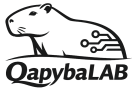

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **LAB TOOLS &mdash; Propagação de Incertezas**
# ── Célula 1: propagação de incertezas ──────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo modelos, métodos,
# pacotes a serem usados e linhas gerais da inteface gráfica, mas a maior parte
# do código, especialmente as funções para leitura de arquivos e para a
# interface gráfica, foi escrita usando o modelo Claude Sonnet 4.6.
# O código gerado foi inspecionado e sofreu diversas alterações e correções
# realizadas pelo licenciante e pelo modelo Gemini 3.5-flash.


import math, io, base64, unicodedata, warnings
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display, HTML, clear_output, Math

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi":110,"font.size":10,
                             "axes.spines.top":False,
                             "axes.spines.right":False})

# ══════════════════════════════════════════════════════════════════
#  NORMALIZAÇÃO DE NOMES
#  remove acentos e outros diacríticos para uso em nomes de arquivo
# ══════════════════════════════════════════════════════════════════
def nome_para_arquivo(nome):
    """Converte nome com acentos/cedilha para versão segura para nomes
    de arquivo (ex: 'posição' → 'posicao')."""
    nfd = unicodedata.normalize("NFD", nome)
    return "".join(c for c in nfd
                   if unicodedata.category(c) != "Mn"
                   ).replace(" ", "_")

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte LAB/NEWTON TOOLS:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (violeta fixo)
#  Acento desta ferramenta: violeta #7048e8
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#7048e8;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.92rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.92rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.92rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.term-t{border-collapse:collapse;font-size:.85rem;width:70%;margin:6px 0;}
.term-t th{background:#1a1a2e;color:#fff;padding:5px 12px;text-align:center;}
.term-t td{padding:5px 12px;border-bottom:1px solid #eee;
  font-family:monospace;text-align:center;}
.term-t tr:nth-child(even) td{background:#f5f0ff;}
.eq-box{background:#1a1a2e;color:#d8d8ff;font-family:monospace;
  font-size:.93rem;padding:10px 16px;border-radius:8px;
  margin:8px 0;line-height:1.8;}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  MATEMÁTICA
# ══════════════════════════════════════════════════════════════════

# Símbolos reservados do SymPy que NÃO devem ser tratados como variáveis
_RESERVADOS = {"I","E","S","N","C","O","Q","pi","zoo","nan","oo",
               "true","false","True","False"}

# Namespace seguro: todas as funções do SymPy, sem os símbolos reservados
_SAFE_NS = {k: getattr(sp, k) for k in dir(sp)
            if not k.startswith("_") and k not in _RESERVADOS}
_SAFE_NS["pi"] = sp.pi

def _parse_expr(expr_str, nomes_vars):
    """
    Parseia a string da equação criando símbolos positivos para as
    variáveis definidas pelo aluno — evita conflito com sp.I, sp.E etc.
    """
    syms = {nm: sp.Symbol(nm, positive=True) for nm in nomes_vars}
    ns   = {**_SAFE_NS, **syms}
    return sp.sympify(expr_str, locals=ns), syms

def _eval_seguro(expr_sym, subs):
    """Avalia numericamente, retornando a parte real do resultado."""
    v = expr_sym.subs(subs).evalf()
    return float(sp.re(v))

def detectar_variaveis(expr_str):
    """Detecta variáveis sem contexto de nomes definidos."""
    try:
        expr = sp.sympify(expr_str, locals=_SAFE_NS)
        return sorted(expr.free_symbols, key=lambda s: s.name)
    except Exception:
        return []

def calcular_propagacao(expr_str, nomes_vars, valores, incertezas):
    """
    Retorna dict com todos os resultados da propagação.
    Usa símbolos positivos para evitar conflitos com constantes do SymPy.
    """
    expr, syms = _parse_expr(expr_str, nomes_vars)
    variaveis  = sorted(expr.free_symbols, key=lambda s: s.name)
    subs_num   = {syms[nm]: valores[nm] for nm in nomes_vars if nm in syms}

    derivadas_sym = {}
    derivadas_num = {}
    termos        = {}

    for v in variaveis:
        df      = sp.diff(expr, v)
        df_simp = sp.simplify(df)
        df_n    = _eval_seguro(df_simp, subs_num)
        u_v     = incertezas[v.name]
        derivadas_sym[v] = df_simp
        derivadas_num[v] = df_n
        termos[v]        = (df_n ** 2) * (u_v ** 2)

    soma    = sum(termos.values())
    u_y     = math.sqrt(soma) if soma >= 0 else float("nan")
    valor_f = _eval_seguro(expr, subs_num)

    contrib_rel = {v: (termos[v]/soma*100 if soma > 0 else 0.0)
                   for v in variaveis}

    return dict(
        expr=expr, variaveis=variaveis, syms=syms,
        derivadas_sym=derivadas_sym, derivadas_num=derivadas_num,
        termos=termos, soma=soma,
        u_y=u_y, valor_f=valor_f, contrib_rel=contrib_rel,
    )

def fmt_sig(v, sig=4):
    v = float(v)
    if not math.isfinite(v) or v == 0: return str(v)
    d = int(math.floor(math.log10(abs(v)))) - (sig-1)
    return (f"{round(v,-d):.{max(0,-d)}f}" if d >= 0 else f"{v:.{-d}f}")

# ══════════════════════════════════════════════════════════════════
#  GRÁFICOS
# ══════════════════════════════════════════════════════════════════
CORES = ["#7048e8","#3b5bdb","#2f9e44","#e67700",
         "#c92a2a","#1098ad","#f76707","#9c36b5"]

def gerar_grafico(variaveis, contrib_rel, termos, nome_f):
    labels  = [v.name for v in variaveis]
    vals_pc = [contrib_rel[v] for v in variaveis]
    cores   = [CORES[i % len(CORES)] for i in range(len(variaveis))]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    # Pizza — contribuições relativas
    ax1 = axes[0]
    wedges, texts, autotexts = ax1.pie(
        vals_pc, labels=labels, colors=cores,
        autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=1.5))
    for at in autotexts: at.set_fontsize(9)
    ax1.set_title(f"Contribuições relativas\npara u({nome_f})",
                  fontsize=10, pad=10)

    # Barras — |∂f/∂xᵢ|·uᵢ
    ax2 = axes[1]
    raizes = [math.sqrt(abs(termos[v])) for v in variaveis]
    bars   = ax2.barh(labels[::-1], raizes[::-1],
                      color=cores[::-1], edgecolor="white",
                      linewidth=0.8, height=0.55)
    ax2.set_xlabel("|∂f/∂xᵢ| · uᵢ", fontsize=10)
    ax2.set_title("Contribuição absoluta\npor variável",
                  fontsize=10, pad=10)
    ax2.set_facecolor("#fafafa")
    max_r = max(raizes) if raizes else 1
    for bar, val in zip(bars, raizes[::-1]):
        ax2.text(bar.get_width() + max_r*0.02,
                 bar.get_y() + bar.get_height()/2,
                 fmt_sig(val,3), va="center", fontsize=8, color="#333")
    ax2.set_xlim(0, max_r * 1.22)

    plt.tight_layout(pad=2.0)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    return (f'<img src="data:image/png;base64,{b64}" '
            f'style="width:100%;max-width:860px;border-radius:6px;'
            f'box-shadow:0 2px 8px rgba(0,0,0,.13)">')

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS
# ══════════════════════════════════════════════════════════════════
def h(tag, content, **attrs):
    a = " ".join(f'{k.rstrip("_")}="{v}"' for k,v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"

def card(s, c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    """Constrói o HTML de um rótulo de seção (classe .sec)."""
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    """Widget HTML com um rótulo de seção — forma padrão de criar
    títulos de seção em toda a suíte LAB/NEWTON TOOLS."""
    return w.HTML(sec_html(texto, estilo))

def tabela_termos_html(variaveis, valores, res, incertezas):
    ths = "".join(h("th",t) for t in [
        "Variável","xᵢ","uᵢ",
        "∂f/∂xᵢ  (numérico)",
        "|∂f/∂xᵢ| · uᵢ",
        "(∂f/∂xᵢ · uᵢ)²",
        "Contribuição"])
    rows = ""
    max_c = max(res["contrib_rel"].values()) if res["contrib_rel"] else 0
    for v in variaveis:
        nm   = v.name
        df_n = res["derivadas_num"][v]
        u_v  = incertezas[nm]
        t    = res["termos"][v]
        raiz = math.sqrt(abs(t))
        cont = res["contrib_rel"][v]
        destaque = 'style="background:#ede9ff"' if cont == max_c else ""
        rows += f"<tr {destaque}>" + "".join(h("td",c) for c in [
            h("b",nm), fmt_sig(valores[nm],5), fmt_sig(u_v,4),
            fmt_sig(df_n,4), fmt_sig(raiz,4),
            fmt_sig(t,4), f"{cont:.1f}%"]) + "</tr>"
    return h("table", h("thead",h("tr",ths))+h("tbody",rows),
             class_="term-t")

# ══════════════════════════════════════════════════════════════════
#  WIDGETS
# ══════════════════════════════════════════════════════════════════
ES   = {"description_width":"160px"}
FULL = w.Layout(width="100%")

cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; LAB TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">🔢 Propagação de Incertezas</div>
</div>
''')

display(w.VBox([cabecalho]))

# ── Equação ──────────────────────────────────────────────────────
display(titulo_secao('⚙ Equação do modelo'))

wnome_f  = w.Text(value="y", description="Nome da grandeza:",
                  style=ES, layout=w.Layout(width="240px"),
                  placeholder="ex: V, F, T")
wequacao = w.Text(value="",
                  description="f(x₁, x₂, …) =",
                  style=ES, layout=w.Layout(width="580px"),
                  placeholder="ex: m*g*h  ou  2*pi*sqrt(L/g)")
wpreview = w.HTML("")
display(w.HBox([wnome_f, wequacao]))
display(wpreview)

# ── Variáveis ────────────────────────────────────────────────────
display(titulo_secao('📋 Variáveis'))
wmodo = w.ToggleButtons(
    options=["🔍 Detectar automaticamente","✏️ Definir manualmente"],
    value="🔍 Detectar automaticamente",
    layout=w.Layout(margin="4px 0 10px"))
display(wmodo)

wvar_container = w.VBox([], layout=FULL)
wvar_hint = w.HTML(
    '<small style="color:#888">Clique em <b>🔍 Detectar variáveis</b> '
    'após digitar a equação.</small>')
display(wvar_hint, wvar_container)

def fazer_bloco_var(nome_sug="x", val=1.0, unc=0.1, unid=""):
    wnome = w.Text(value=nome_sug, description="Símbolo:",
                   style={"description_width":"75px"},
                   layout=w.Layout(width="175px"))
    wval  = w.FloatText(value=val, description="Valor:",
                        style={"description_width":"55px"},
                        layout=w.Layout(width="195px"))
    wunc  = w.FloatText(value=unc, description="Incerteza u:",
                        style={"description_width":"95px"},
                        layout=w.Layout(width="215px"))
    wunid = w.Text(value=unid, description="Unidade:",
                   style={"description_width":"65px"},
                   layout=w.Layout(width="170px"),
                   placeholder="ex: kg")
    bloco = w.HBox([wnome,wval,wunc,wunid],
                   layout=w.Layout(border="1px solid #d5c9ff",
                                   border_radius="7px",
                                   padding="7px 12px",margin="4px 0"))
    bloco._wnome=wnome; bloco._wval=wval
    bloco._wunc=wunc;   bloco._wunid=wunid
    return bloco

def _detectar(*_):
    estr = wequacao.value.strip()
    if not estr:
        wpreview.value=card("⚠ Digite a equação primeiro.","wcard"); return
    try:
        # Detecção prévia sem símbolos positivos (para listar nomes)
        vars_prev = detectar_variaveis(estr)
        nomes_prev = [v.name for v in vars_prev]
        # Releitura com símbolos positivos para evitar sp.I etc.
        expr, syms = _parse_expr(estr, nomes_prev)
        variaveis  = sorted(expr.free_symbols, key=lambda s: s.name)
    except Exception as e:
        wpreview.value=card(f"✘ Erro: {e}","ecard"); return

    # Preserva valores já inseridos
    ant = {b._wnome.value:(b._wval.value,b._wunc.value,b._wunid.value)
           for b in wvar_container.children
           if hasattr(b,"_wnome")}
    blocos = []
    for v in variaveis:
        val,unc,unid = ant.get(v.name,(1.0,0.1,""))
        blocos.append(fazer_bloco_var(v.name,val,unc,unid))
    wvar_container.children = tuple(blocos)

    nome_f = wnome_f.value or "y"
    try:
        latex_eq = sp.latex(expr)
        wpreview.value=(
            f'<div class="eq-box">'
            f'{nome_f} &nbsp;=&nbsp; {latex_eq}'
            f'<br><small style="color:#aaa">Variáveis detectadas: '
            +", ".join(f"<b>{v.name}</b>" for v in variaveis)
            +"</small></div>")
    except Exception:
        wpreview.value=card(f"Equação: {estr}","rcard")

    wvar_hint.value=(
        f'<small style="color:#555">{len(variaveis)} variável(is) '
        f'detectada(s). Preencha valor e incerteza.</small>')

# Botão detectar
btn_detect = w.Button(description="🔍 Detectar variáveis",
                      button_style="info",
                      layout=w.Layout(width="210px",margin="4px 0"))
btn_detect.on_click(_detectar)

# Modo manual
wn_vars   = w.BoundedIntText(value=2,min=1,max=12,
                              description="Nº de variáveis:",
                              style=ES,layout=w.Layout(width="260px"))
btn_criar = w.Button(description="Criar campos",button_style="",
                     icon="plus",layout=w.Layout(width="150px"))
wn_vars_box = w.HBox([wn_vars,btn_criar])

def _criar_manual(_):
    blocos=[fazer_bloco_var(f"x{i+1}" if i else "x")
            for i in range(wn_vars.value)]
    wvar_container.children=tuple(blocos)

btn_criar.on_click(_criar_manual)

def _on_modo(change):
    if change["new"]=="🔍 Detectar automaticamente":
        wvar_container.children=()
        wvar_hint.value=('<small style="color:#888">Clique em '
                         '<b>🔍 Detectar variáveis</b> após digitar '
                         'a equação.</small>')
    else:
        wvar_container.children=(wn_vars_box,)
        wvar_hint.value=('<small style="color:#888">Informe o número '
                         'de variáveis e clique em <b>Criar campos</b>.'
                         '</small>')

wmodo.observe(_on_modo,names="value")
display(btn_detect)

# ══════════════════════════════════════════════════════════════════
#  BOTÃO DE EXECUÇÃO
# ══════════════════════════════════════════════════════════════════
display(HTML('<div style="margin:14px 0 4px"></div>'))
btn   = w.Button(description="▶  Calcular incerteza",
                 button_style="primary",icon="calculator",
                 layout=w.Layout(width="240px",height="40px"))
saida = w.Output()
display(w.HBox([btn]),saida)

# ══════════════════════════════════════════════════════════════════
#  CALLBACK PRINCIPAL
# ══════════════════════════════════════════════════════════════════
def _on_calcular(_):
    with saida:
        clear_output(wait=True)

        nome_f = wnome_f.value.strip() or "y"
        estr   = wequacao.value.strip()

        if not estr:
            display(HTML(card("⚠ Digite a equação do modelo.","wcard")))
            return

        blocos = [b for b in wvar_container.children
                  if hasattr(b,"_wnome")]
        if not blocos:
            display(HTML(card(
                "⚠ Clique em <b>🔍 Detectar variáveis</b> ou "
                "defina as variáveis manualmente.","wcard")))
            return

        # Coleta dados dos widgets
        valores={}; incertezas={}; unidades={}; erros=[]
        for b in blocos:
            nm = b._wnome.value.strip()
            if not nm:
                erros.append("Símbolo de variável vazio."); continue
            if not nm.replace("_","").isalnum():
                erros.append(f"Símbolo inválido: '{nm}'."); continue
            if nm in _RESERVADOS:
                erros.append(
                    f"'{nm}' é reservado pelo SymPy. "
                    f"Use outro nome (ex: '{nm}{nm}' ou '{nm}1').")
                continue
            u = b._wunc.value
            if u <= 0:
                erros.append(f"Incerteza de '{nm}' deve ser > 0.")
                continue
            valores[nm]    = b._wval.value
            incertezas[nm] = u
            unidades[nm]   = b._wunid.value.strip()

        if erros:
            display(HTML(card("✘ "+"<br>".join(erros),"ecard")))
            return

        # Verifica cobertura de variáveis
        try:
            vars_expr = {v.name for v in detectar_variaveis(estr)}
        except Exception as e:
            display(HTML(card(f"✘ Erro na equação: {e}","ecard")))
            return
        nao_def    = vars_expr - set(valores)
        nao_usadas = set(valores) - vars_expr
        if nao_def:
            display(HTML(card(
                f"✘ Variável(is) sem valor: "
                f"<b>{', '.join(sorted(nao_def))}</b>","ecard")))
            return
        if nao_usadas:
            display(HTML(card(
                f"⚠ Definida(s) mas não usada(s) na equação: "
                f"<b>{', '.join(sorted(nao_usadas))}</b>","wcard")))

        # ── Calcula ───────────────────────────────────────────
        try:
            res = calcular_propagacao(estr,list(valores.keys()),
                                      valores,incertezas)
        except Exception as e:
            display(HTML(card(f"✘ Erro no cálculo: {e}","ecard")))
            return

        variaveis = res["variaveis"]
        valor_f   = res["valor_f"]
        u_y       = res["u_y"]

        # ── Fórmula geral ─────────────────────────────────────
        display(titulo_secao('📐 Fórmula geral de propagação'))
        termos_latex = []
        for v in variaveis:
            termos_latex.append(
                r"\left(\frac{\partial " + nome_f
                + r"}{\partial " + sp.latex(v)
                + r"}\right)^{\!2} u_{" + v.name + r"}^{2}")
        display(Math(
            r"u_{"+nome_f+r"} = \sqrt{"
            +r" + ".join(termos_latex)+r"}"))

        # ── Derivadas parciais ────────────────────────────────
        display(titulo_secao('∂ Derivadas parciais'))
        for v in variaveis:
            df_sym = res["derivadas_sym"][v]
            df_num = res["derivadas_num"][v]
            u_v    = incertezas[v.name]
            lhs    = (r"\frac{\partial "+nome_f+r"}{\partial "
                      +sp.latex(v)+"}")
            # Linha 1: expressão simbólica
            display(Math(lhs+" = "+sp.latex(df_sym)))
            # Linha 2: valor numérico e contribuição
            display(HTML(card(
                f"<b>∂{nome_f}/∂{v.name}</b>"
                f" &nbsp;=&nbsp; {fmt_sig(df_num,5)}"
                f" &nbsp;|&nbsp; "
                f"u_{v.name} = {fmt_sig(u_v,4)}"
                f" &nbsp;|&nbsp; "
                f"|∂f/∂{v.name}|·u_{v.name}"
                f" = {fmt_sig(math.sqrt(abs(res['termos'][v])),4)}")))

        # ── Tabela de termos ──────────────────────────────────
        display(titulo_secao('📊 Tabela de termos'))
        display(HTML(tabela_termos_html(
            variaveis,valores,res,incertezas)))

        # ── Resultado ─────────────────────────────────────────
        display(titulo_secao('✔ Resultado final'))
        display(HTML(card(
            f"<b>{nome_f}</b> &nbsp;=&nbsp; {fmt_sig(valor_f,5)}")))
        display(HTML(card(
            f"<b>u({nome_f})</b> &nbsp;=&nbsp; {fmt_sig(u_y,4)}")))
        display(HTML(card(
            f"<b>Resultado:</b> &nbsp; "
            f"{nome_f} = ( {fmt_sig(valor_f,4)} "
            f"&nbsp;±&nbsp; {fmt_sig(u_y,4)} )","gcard")))
        if valor_f != 0 and math.isfinite(u_y):
            u_rel = abs(u_y/valor_f)*100
            display(HTML(card(
                f"Incerteza relativa: "
                f"u({nome_f})/{nome_f} = {u_rel:.2f}%")))

        # ── Gráfico ───────────────────────────────────────────
        display(titulo_secao('📈 Contribuições por variável'))
        display(HTML(gerar_grafico(
            variaveis,res["contrib_rel"],res["termos"],nome_f)))

        # ── Download CSV ──────────────────────────────────────
        linhas=["grandeza,valor,incerteza,unidade"]
        for v in variaveis:
            nm=v.name
            linhas.append(",".join([nm,str(valores[nm]),
                str(incertezas[nm]),unidades.get(nm,"")]))
        linhas+=["",f"resultado,{fmt_sig(valor_f,6)},{fmt_sig(u_y,6)},",""]
        linhas+=["variavel,df_dxi_num,|df_dxi|*ui,(df_dxi*ui)^2,contrib_%"]
        for v in variaveis:
            nm=v.name
            t=res["termos"][v]
            linhas.append(",".join([
                nm, fmt_sig(res["derivadas_num"][v],6),
                fmt_sig(math.sqrt(abs(t)),6), fmt_sig(t,6),
                f"{res['contrib_rel'][v]:.2f}"]))
        csv_b64=base64.b64encode("\n".join(linhas).encode()).decode()
        nome_f_arq = nome_para_arquivo(nome_f)
        display(HTML(
            f'<a href="data:text/csv;base64,{csv_b64}" '
            f'download="propagacao_{nome_f_arq}.csv" '
            f'style="display:inline-block;margin-top:12px;padding:6px 16px;'
            f'background:#7048e8;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.88rem">'
            f'⬇ Baixar resultados CSV</a>'))

btn.on_click(_on_calcular)